# San Diego Neighborhood Opportunity Finder  
## Exploratory Data Analysis

I'm specifically looking into residential and mixed-use census tracts across San Diego County to identify neighborhoods that could have potential for residential development or community investment. It combines demographic, housing, safety, transportation, walkability, environmental risk, and school access data.

This notebook uses the final residential tract dataset created during the data wrangling and merge process.

Questions to answer:

- Which tracts look strong across several neighborhood factors?
- Which areas have better safety, walkability, transit, or school access?
- Which areas have higher climate or environmental risk?
- Are there tradeoffs between different neighborhood features?
- Which variables seem most useful for the final scoring system?

This notebook won’t create the final opportunity score yet. My goal is to understand the data, review feature relationships, and decide which variables should move forward into scoring.

General things I'm looking into: 

- feature distributions
- relationships between neighborhood factors
- top and bottom tract comparisons
- geographic patterns
- possible outliers or skewed features
- limitations that could affect scoring

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# prefered theme
sns.set_theme(style='whitegrid', palette='Set2')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
data_path = Path(
    '../data/processed/master_residential_tract_features_final.csv')

df = pd.read_csv(
    data_path,
    dtype={'tract_id': str})

df.shape

(727, 75)

In [3]:
# checking the dataset before starting EDA

eda_checks = pd.Series({
    'rows': len(df),
    'columns': df.shape[1],
    'unique_tract_ids': df['tract_id'].nunique(),
    'duplicate_tract_ids': df['tract_id'].duplicated().sum(),
    'total_missing_values': df.isna().sum().sum()})

eda_checks

rows                    727
columns                  75
unique_tract_ids        727
duplicate_tract_ids       0
total_missing_values     87
dtype: int64

In [4]:
# grouping columns so the EDA is easier to manage

demographic_housing_features = [
    'median_household_income',
    'poverty_rate',
    'family_poverty_rate',
    'unemployment_rate',
    'renter_rate',
    'estimated_median_gross_rent',
    'vacancy_rate',
    'avg_household_size',
    'population_under_18_rate']

safety_features = [
    'safety_score',
    'violent_safety_score',
    'property_safety_score',
    'crime_rate_per_1000',
    'violent_crime_rate_per_1000',
    'property_crime_rate_per_1000']

walkability_transit_features = [
    'walkability_index',
    'jobs_housing_mix_score',
    'employment_mix_score',
    'intersection_density_score',
    'commute_mode_diversity_score',
    'transit_stop_density',
    'public_transit_commute_rate',
    'no_vehicle_rate']

environment_features = [
    'climate_loss_risk_score',
    'social_vulnerability_score',
    'heat_risk_score',
    'flood_risk_score',
    'wildfire_risk_score']

school_features = [
    'school_density',
    'school_academic_score',
    'school_count',
    'elementary_school_count',
    'middle_school_count',
    'high_school_count']

In [5]:
# reviewing the main features before making charts

core_eda_features = [
    'walkability_index',
    'transit_stop_density',
    'climate_loss_risk_score',
    'social_vulnerability_score',
    'school_academic_score',
    'school_density',
    'median_household_income',
    'estimated_median_gross_rent',
    'poverty_rate',
    'renter_rate']

core_summary = (
    df[core_eda_features]
    .describe()
    .T
    .round(2))

core_summary

,count,mean,std,min,25%,50%,75%,max
walkability_index,727.0,12.03,3.30,3.50,9.83,12.61,14.51,19.50
transit_stop_density,727.0,14.28,17.83,0.00,1.84,9.39,20.94,243.55
climate_loss_risk_score,727.0,49.09,26.89,1.76,26.73,45.42,68.97,99.99
social_vulnerability_score,727.0,39.33,27.29,9.21,9.21,33.90,60.53,98.59
school_academic_score,727.0,3.13,1.02,1.50,2.00,3.50,3.50,5.00
school_density,727.0,1.43,2.10,0.00,0.00,0.74,2.03,21.74
median_household_income,719.0,113699.13,41987.85,34148.00,81065.00,109750.00,138850.50,247222.00
estimated_median_gross_rent,727.0,2374.23,527.12,629.00,1936.00,2337.00,2815.00,3482.00
poverty_rate,727.0,10.31,7.60,0.00,5.00,8.20,13.70,48.00
renter_rate,727.0,44.10,25.21,2.30,22.05,41.90,63.90,100.00


## Score Reference

- ` safety_score `: Overall safety score from the crime/safety notebook. It combines crime patterns into one general safety measure. Higher is better.

- ` violent_safety_score `: Safety score focused on violent crime from the crime/safety notebook. Higher is better.

- ` property_safety_score `: Safety score focused on property crime from the crime/safety notebook. Higher is better.

- ` climate_loss_risk_score `: expected annual loss risk from the environmental risk data. This was renamed from `expected_annual_loss_score_composite`. Lower is better.

- ` social_vulnerability_score `: Social vulnerability score from the environmental risk data. It gives an idea of how vulnerable a tract’s population could be during hazards or stress events. Lower is better.

- ` heat_risk_score `: Heat hazard risk score from the environmental risk data. Lower is better.

- ` flood_risk_score `: Inland flood hazard risk score from the environmental risk data. Lower is better.

- ` wildfire_risk_score `: Wildfire hazard risk score from the environmental risk data. Lower is better.

- ` school_academic_score `: Simple school strength score from the schools notebook, based on available school performance fields. Higher is better.

Safety and school scores are positive features, so higher is better. Environmental risk scores are risk features, so lower is better. If I use risk scores later, I’ll probably need to reverse them before combining them into one opportunity score.

## Feature distribution and outlier review

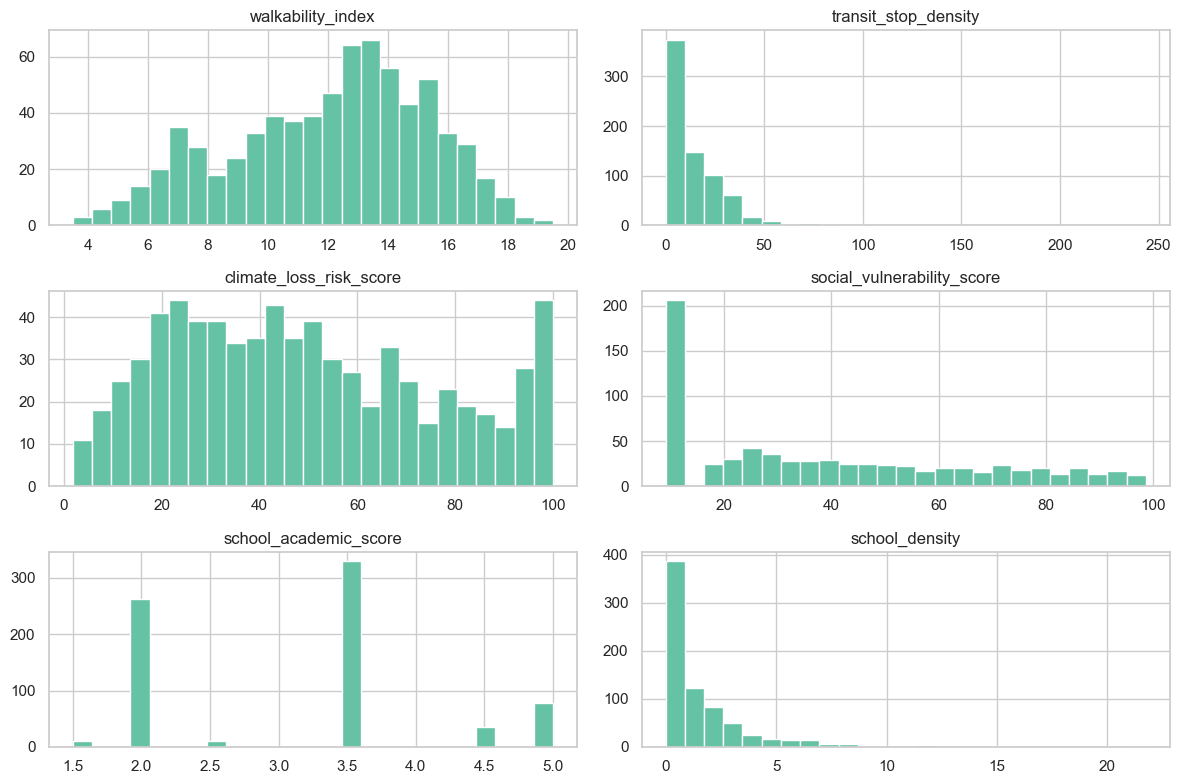

In [6]:
# checking the main feature distributions before comparing tracts

distribution_features = [
    'walkability_index',
    'transit_stop_density',
    'climate_loss_risk_score',
    'social_vulnerability_score',
    'school_academic_score',
    'school_density']

df[distribution_features].hist(
    figsize=(12, 8),
    bins=25)

plt.tight_layout()
plt.show()

- Walkability: widespread across tracts
- Climate risk: widespread across tracts
- Transit stop density: heavily skewed
- School density: heavily skewed, with most tracts near the lower end and a few very high values
- Social vulnerability: Clustered at the minimum -- needs a closer look
- School academic score: should look at this in a different way since it's more categorical

In [7]:
# checking the skewed features before deciding how to scale them later

skewed_features = [
    'transit_stop_density',
    'school_density',
    'social_vulnerability_score']

df[skewed_features].quantile(
    [
        0,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1
    ]).round(2)

,transit_stop_density,school_density,social_vulnerability_score
0.00,0.00,0.00,9.21
0.25,1.84,0.00,9.21
0.50,9.39,0.74,33.90
0.75,20.94,2.03,60.53
0.90,33.48,3.92,80.95
0.95,41.05,5.67,90.00
0.99,73.55,8.20,95.90
1.00,243.55,21.74,98.59


- transit_stop_density has a median of 9.39, but the max is 243.55.
- school_density has a median of 0.74, but the max is 21.74.

In [8]:
# checking why social vulnerability has a large cluster at the minimum

min_social_vulnerability = (
    df['social_vulnerability_score'].min())

social_vulnerability_min_check = pd.Series({
    'minimum_value': min_social_vulnerability,
    'tracts_at_minimum': (
        df['social_vulnerability_score']
        == min_social_vulnerability
    ).sum(),
    'percent_at_minimum': (
        (
            df['social_vulnerability_score']
            == min_social_vulnerability
        ).mean()
        * 100)})

social_vulnerability_min_check.round(2)

minimum_value           9.21
tracts_at_minimum     206.00
percent_at_minimum     28.34
dtype: float64

I’m checking these values because a few outliers or repeated values could affect the final score. I want each feature to separate tracts in a useful way. If one value stands out or a lot of tracts have the same value, I might need to transform it, rank it, or leave it out.

In [9]:
# checking the most common social vulnerability values

df['social_vulnerability_score'].value_counts().head(10)

social_vulnerability_score
9.209856     206
19.791506      5
22.229462      3
22.742996      3
26.429545      2
17.892555      2
27.617722      2
23.982705      2
28.493751      2
22.914766      2
Name: count, dtype: int64

In [10]:
# checking how much of the dataset shares the minimum vulnerability score

min_sv_score = df['social_vulnerability_score'].min()

min_sv_count = (
    df['social_vulnerability_score']
    .eq(min_sv_score)
    .sum())

min_sv_pct = (
    min_sv_count
    / len(df)
    * 100)

print('Minimum score:', round(min_sv_score, 6))
print('Tracts at minimum:', min_sv_count)
print('Percent of tracts:', round(min_sv_pct, 2))

Minimum score: 9.209856
Tracts at minimum: 206
Percent of tracts: 28.34


In [12]:
# checking whether the minimum score matches one repeated FEMA rating

df.loc[
    df['social_vulnerability_score'] == min_sv_score,
    'social_vulnerability_rating'].value_counts(dropna=False)

social_vulnerability_rating
Very Low    206
Name: count, dtype: int64

In [14]:
# checking how much the score varies within each original rating

df.groupby(
    'social_vulnerability_rating')['social_vulnerability_score'].agg(
    ['count', 'min', 'median', 'max']).round(2)

,count,min,median,max
social_vulnerability_rating,,,,
Relatively High,106,60.03,70.52,79.93
Relatively Low,183,20.09,28.74,39.95
Relatively Moderate,124,40.01,49.08,59.95
Very High,81,80.31,88.86,98.59
Very Low,233,9.21,9.21,19.96


- Relatively Low: about 20 to 40
- Relatively Moderate: 40 to 60
- Relatively High ranges: 60 to 80
- Very High ranges: 80 to 99

In [16]:
# checking percentiles before deciding how to transform skewed features

skewed_features = [
    'transit_stop_density',
    'school_density',
    'social_vulnerability_score']

df[skewed_features].quantile(
    [
        0,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1]).round(2)

,transit_stop_density,school_density,social_vulnerability_score
0.00,0.00,0.00,9.21
0.25,1.84,0.00,9.21
0.50,9.39,0.74,33.90
0.75,20.94,2.03,60.53
0.90,33.48,3.92,80.95
0.95,41.05,5.67,90.00
0.99,73.55,8.20,95.90
1.00,243.55,21.74,98.59


In [22]:
# checking the tracts with the highest transit density

top_transit_tracts = df.nlargest(
    10,
    'transit_stop_density'
).round(2)[
    [
        'tract_id',
        'tract_name',
        'transit_stop_density',
        'transit_stop_count']]

top_transit_tracts

,tract_id,tract_name,transit_stop_density,transit_stop_count
108,06073005202,Census Tract 52.02; San Diego County; California,243.55,22
110,06073005302,Census Tract 53.02; San Diego County; California,131.36,24
105,06073005102,Census Tract 51.02; San Diego County; California,102.67,9
109,06073005301,Census Tract 53.01; San Diego County; California,97.58,15
116,06073005700,Census Tract 57; San Diego County; California,85.59,9
29,06073002202,Census Tract 22.02; San Diego County; California,85.11,16
112,06073005402,Census Tract 54.02; San Diego County; California,75.19,23
101,06073004800,Census Tract 48; San Diego County; California,73.55,16
16,06073001301,Census Tract 13.01; San Diego County; California,73.54,10
307,06073012302,Census Tract 123.02; San Diego County; California,69.91,11


Some of these tracts are very dense, so my assumption is that the tracts are small. I'll divide the density by the count.

In [24]:
# checking the tracts with the highest school density

top_school_tracts = df.nlargest(
    10,
    'school_density').round(2)[
    [
        'tract_id',
        'tract_name',
        'school_density',
        'school_count'
    ]]

top_school_tracts

,tract_id,tract_name,school_density,school_count
28,06073002201,Census Tract 22.01; San Diego County; California,21.74,3
107,06073005201,Census Tract 52.01; San Diego County; California,15.37,3
23,06073001802,Census Tract 18.02; San Diego County; California,11.87,2
105,06073005102,Census Tract 51.02; San Diego County; California,11.41,1
639,06073020028,Census Tract 200.28; San Diego County; California,11.33,2
665,06073020207,Census Tract 202.07; San Diego County; California,9.38,3
22,06073001801,Census Tract 18.01; San Diego County; California,8.25,1
415,06073015704,Census Tract 157.04; San Diego County; California,8.24,3
42,06073002708,Census Tract 27.08; San Diego County; California,8.10,2
117,06073005801,Census Tract 58.01; San Diego County; California,7.84,1


In [25]:
# checking whether high density values are caused by very small tract areas

density_check = df.loc[
    df['tract_id'].isin(
        top_transit_tracts['tract_id'].tolist()
        + top_school_tracts['tract_id'].tolist()),
    [
        'tract_id',
        'tract_name',
        'transit_stop_count',
        'transit_stop_density',
        'school_count',
        'school_density'
    ]].copy()

density_check['transit_area_sq_mile'] = (
    density_check['transit_stop_count']
    / density_check['transit_stop_density'])

density_check['school_area_sq_mile'] = (
    density_check['school_count']
    / density_check['school_density'])

density_check.round(3).sort_values(
    'transit_stop_density',
    ascending=False)

,tract_id,tract_name,transit_stop_count,transit_stop_density,school_count,school_density,transit_area_sq_mile,school_area_sq_mile
108,06073005202,Census Tract 52.02; San Diego County; California,22,243.555,0,0.000,0.090,NaN
110,06073005302,Census Tract 53.02; San Diego County; California,24,131.356,1,5.473,0.183,0.183
105,06073005102,Census Tract 51.02; San Diego County; California,9,102.667,1,11.408,0.088,0.088
109,06073005301,Census Tract 53.01; San Diego County; California,15,97.576,0,0.000,0.154,NaN
116,06073005700,Census Tract 57; San Diego County; California,9,85.585,0,0.000,0.105,NaN
29,06073002202,Census Tract 22.02; San Diego County; California,16,85.112,1,5.320,0.188,0.188
112,06073005402,Census Tract 54.02; San Diego County; California,23,75.187,1,3.269,0.306,0.306
101,06073004800,Census Tract 48; San Diego County; California,16,73.554,1,4.597,0.218,0.218
16,06073001301,Census Tract 13.01; San Diego County; California,10,73.544,0,0.000,0.136,NaN
307,06073012302,Census Tract 123.02; San Diego County; California,11,69.907,0,0.000,0.157,NaN


In [28]:
# summarizing the implied tract area behind the density outliers

density_check[
    [
        'tract_id',
        'tract_name',
        'transit_stop_count',
        'transit_stop_density',
        'school_count',
        'school_density',
        'transit_area_sq_mile'
    ]].round(3).sort_values(
    'transit_area_sq_mile')

,tract_id,tract_name,transit_stop_count,transit_stop_density,school_count,school_density,transit_area_sq_mile
105,06073005102,Census Tract 51.02; San Diego County; California,9,102.667,1,11.408,0.088
108,06073005202,Census Tract 52.02; San Diego County; California,22,243.555,0,0.000,0.090
116,06073005700,Census Tract 57; San Diego County; California,9,85.585,0,0.000,0.105
22,06073001801,Census Tract 18.01; San Diego County; California,3,24.749,1,8.250,0.121
117,06073005801,Census Tract 58.01; San Diego County; California,1,7.838,1,7.838,0.128
16,06073001301,Census Tract 13.01; San Diego County; California,10,73.544,0,0.000,0.136
28,06073002201,Census Tract 22.01; San Diego County; California,4,28.989,3,21.742,0.138
109,06073005301,Census Tract 53.01; San Diego County; California,15,97.576,0,0.000,0.154
307,06073012302,Census Tract 123.02; San Diego County; California,11,69.907,0,0.000,0.157
23,06073001802,Census Tract 18.02; San Diego County; California,10,59.369,2,11.874,0.168


I might have to rank by percentile or cap at the 99th percentile instead of using raw density because very small tracts can show high density values, even if the actual number of transit stops or schools isn’t unusually large.

## Distribution and summary review

`social_vulnerability_score`: useful across most tracts, but 206 tracts have the same minimum score. This creates a floor effect in the `Very Low` category, so the feature doesn’t fully separate those tracts.

`transit_stop_density` and `school_density`: heavily right-skewed. The highest values mostly come from very small census tracts, not a large numbers of stops or schools.

I might use percentile ranks, log transforms, or cap extreme values later so a few very small tracts don’t dominate the final score. I’ll keep the raw values as is during EDA.

- There is a slightly negative relationship
- More walkable tracts look like they have a somewhat lower estimated rent
- points are spread out, so walkability alone doesn't explain rent very well
- Tracts with similar walkability can still have very different rents

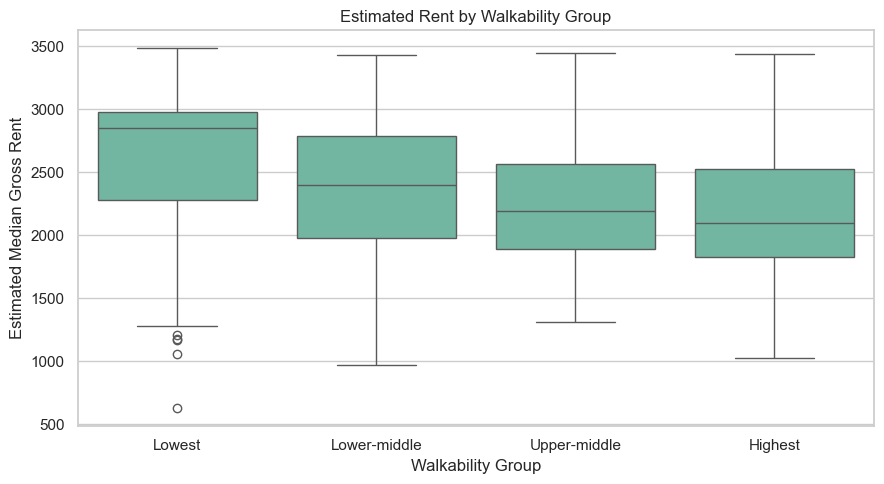

In [31]:
# grouping walkability into quartiles so the rent is easier to compare

walk_rent_plot = df[
    [
        'walkability_index',
        'estimated_median_gross_rent'
    ]].copy()

walk_rent_plot['walkability_group'] = pd.qcut(
    walk_rent_plot['walkability_index'],
    q=4,
    labels=[
        'Lowest',
        'Lower-middle',
        'Upper-middle',
        'Highest'])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=walk_rent_plot,
    x='walkability_group',
    y='estimated_median_gross_rent')

plt.title('Estimated Rent by Walkability Group')
plt.xlabel('Walkability Group')
plt.ylabel('Estimated Median Gross Rent')

plt.tight_layout()
plt.show()

Less walkable tracts seem to be more expensive on average. That could reflect larger suburban homes or higher-income owner-occupied areas.

The grouped comparison shows a clearer pattern than the scatterplot (not shown). Tracts in the lowest walkability group have the highest median estimated rent and the highest walkability group has the lowest median rent.

There is still a lot of overlap between groups.

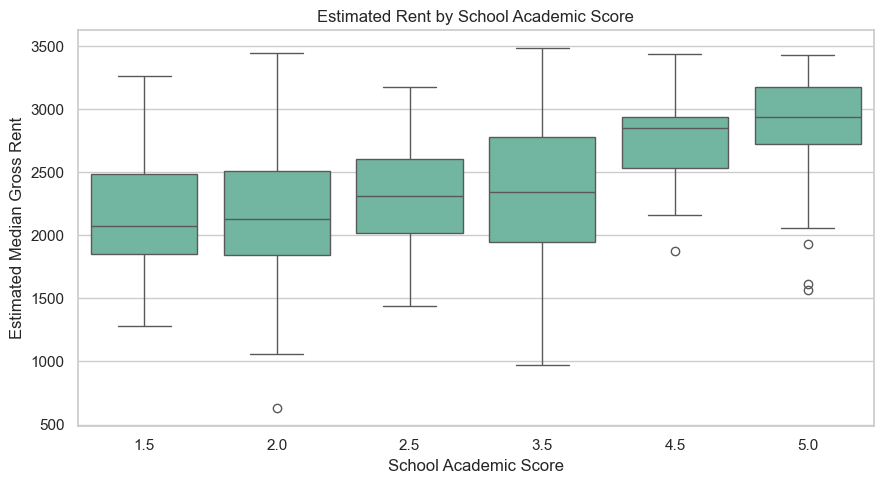

In [32]:
# comparing rent and the school academic score levels

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='school_academic_score',
    y='estimated_median_gross_rent')

plt.title('Estimated Rent by School Academic Score')
plt.xlabel('School Academic Score')
plt.ylabel('Estimated Median Gross Rent')

plt.tight_layout()
plt.show()

<b>Main takeaway:</b>

- Higher school academic scores generally come with higher estimated rent
- Tracts with scores of 4.5 and 5.0 have noticeably higher median rents
- Lower-score groups have wide rent ranges and lower medians
- There is still some overlap, so strong schools don’t automatically mean every tract is expensive

This looks like stronger schools might improve neighborhood opportunity, but they could also push the final ranking toward more expensive tracts

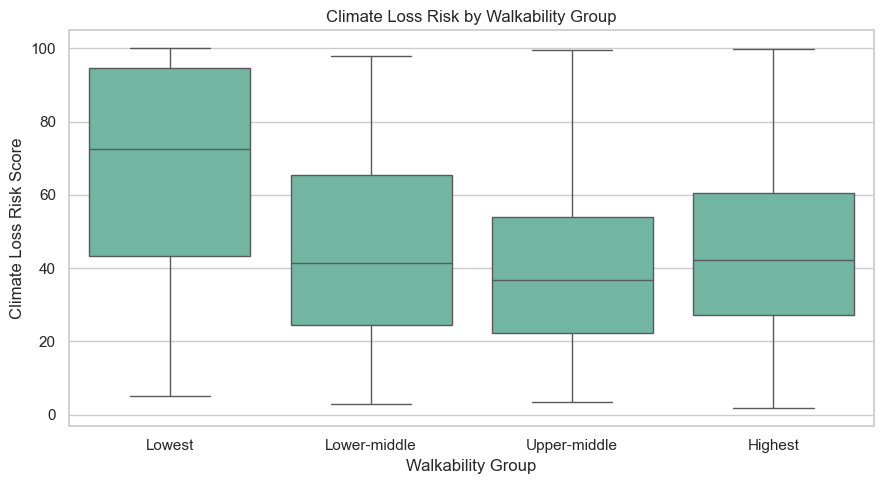

In [34]:
# grouping walkability so the climate risk pattern is easier to compare

walk_climate_plot = df[
    [
        'walkability_index',
        'climate_loss_risk_score'
    ]
].copy()

walk_climate_plot['walkability_group'] = pd.qcut(
    walk_climate_plot['walkability_index'],
    q=4,
    labels=[
        'Lowest',
        'Lower-middle',
        'Upper-middle',
        'Highest'
    ]
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=walk_climate_plot,
    x='walkability_group',
    y='climate_loss_risk_score'
)

plt.title('Climate Loss Risk by Walkability Group')
plt.xlabel('Walkability Group')
plt.ylabel('Climate Loss Risk Score')

plt.tight_layout()
plt.show()

The grouped comparison shows that the lowest-walkability tracts have the highest climate-loss risk overall. This is on track with the idea that suburban areas have higher wildfire exposure, but the climate-loss score includes more than wildfire, so I want to check the wildfire field directly.

The other walkability groups have lower median risk, but there is still a lot of overlap. Higher walkability doesn’t automatically mean lower climate risk, but very low walkability seems connected with higher risk.

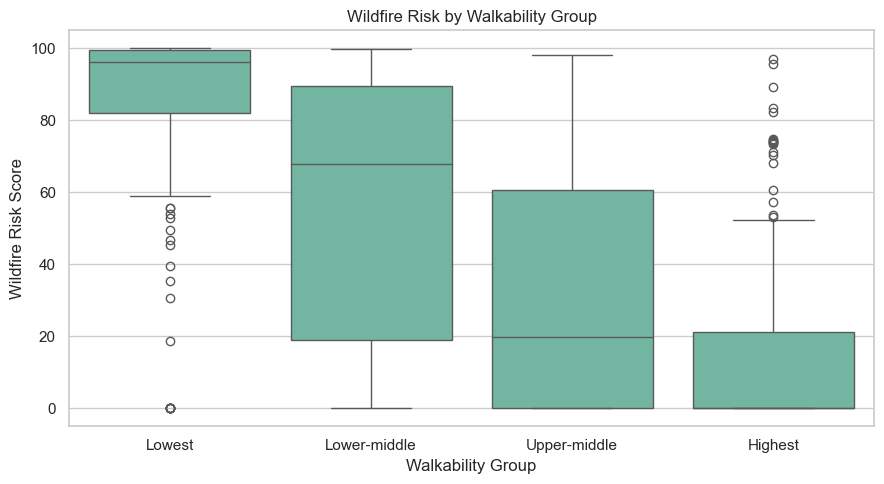

In [37]:
# checking whether wildfire risk helps explain the walkability pattern

walk_wildfire_plot = df[
    [
        'walkability_index',
        'wildfire_risk_score']].copy()

walk_wildfire_plot['walkability_group'] = pd.qcut(
    walk_wildfire_plot['walkability_index'],
    q=4,
    labels=[
        'Lowest',
        'Lower-middle',
        'Upper-middle',
        'Highest'])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=walk_wildfire_plot,
    x='walkability_group',
    y='wildfire_risk_score')

plt.title('Wildfire Risk by Walkability Group')
plt.xlabel('Walkability Group')
plt.ylabel('Wildfire Risk Score')

plt.tight_layout()
plt.show()

Wildfire risk seems to explain a large part of the climate-risk pattern.

The lowest-walkability tracts have very high wildfire risk, and the highest-walkability tracts usually have much lower wildfire risk. I'm curious to see inland flooding now, because it's been a problem in more urban neighborhoods of San Diego. 

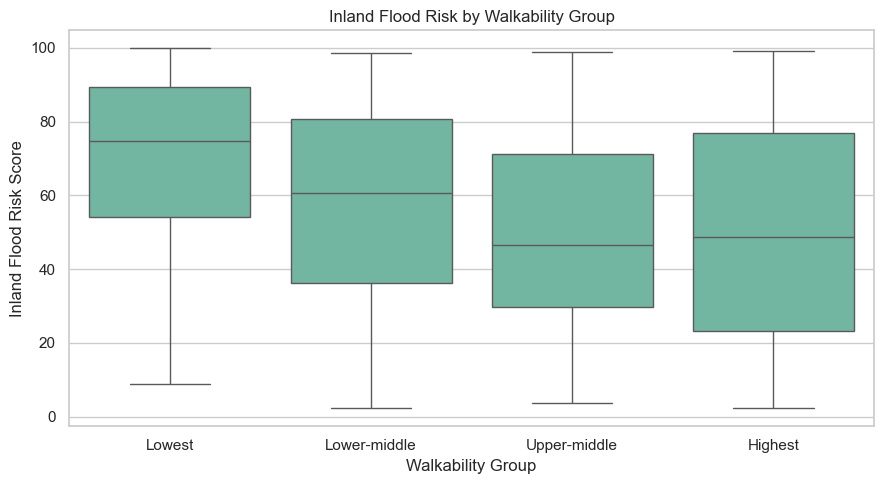

In [39]:
# checking whether inland flood risk is higher in more walkable tracts

walk_flood_plot = df[
    [
        'walkability_index',
        'flood_risk_score']].copy()

walk_flood_plot['walkability_group'] = pd.qcut(
    walk_flood_plot['walkability_index'],
    q=4,
    labels=[
        'Lowest',
        'Lower-middle',
        'Upper-middle',
        'Highest'])

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=walk_flood_plot,
    x='walkability_group',
    y='flood_risk_score')

plt.title('Inland Flood Risk by Walkability Group')
plt.xlabel('Walkability Group')
plt.ylabel('Inland Flood Risk Score')

plt.tight_layout()
plt.show()

Inland flood risk is spread fairly evenly in terms of walkability groups. The lowest-walkability group has a somewhat higher median, but every group has both low- and high-risk tracts. The relationship between walkability and inland flooding isn't as strong as I would have thought. For later analysis, I might want to look into tracts with the highest rate of flooding.

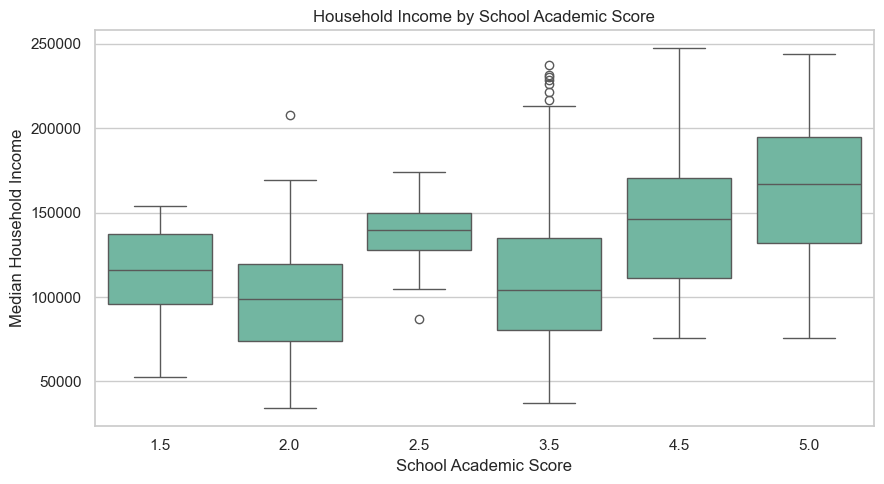

In [38]:
# comparing household income across school academic score levels

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='school_academic_score',
    y='median_household_income')

plt.title('Household Income by School Academic Score')
plt.xlabel('School Academic Score')
plt.ylabel('Median Household Income')

plt.tight_layout()
plt.show()

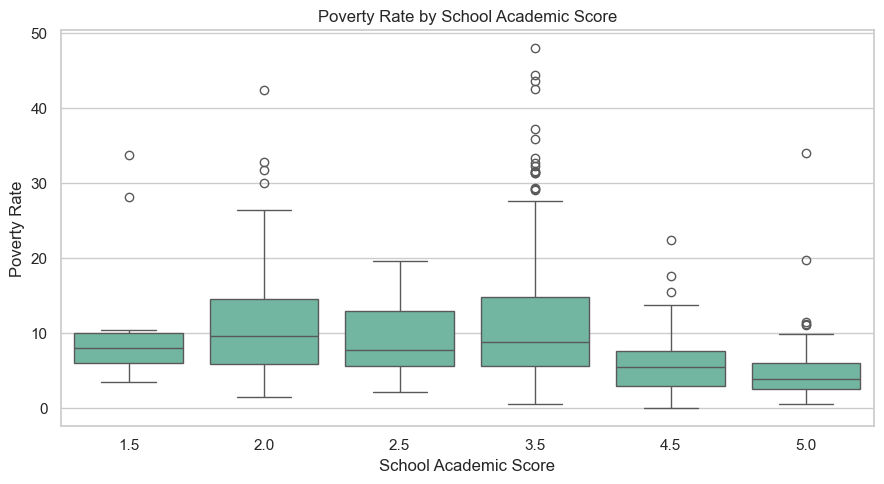

In [40]:
# comparing poverty across school academic score levels

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='school_academic_score',
    y='poverty_rate')

plt.title('Poverty Rate by School Academic Score')
plt.xlabel('School Academic Score')
plt.ylabel('Poverty Rate')

plt.tight_layout()
plt.show()

This is an interesting plot because it shows that low-rated schools have relatively low poverty rates. I'm curious to see why that is and investigate that further. On the opposite end, high-rated schools have a few poverty outliers that I'm interested in exploring as well. 

In [41]:
# checking group sizes and poverty ranges before reviewing specific outliers

school_poverty_summary = (
    df.groupby('school_academic_score')['poverty_rate']
    .agg(
        tract_count='count',
        median_poverty='median',
        min_poverty='min',
        max_poverty='max').round(2))

school_poverty_summary

,tract_count,median_poverty,min_poverty,max_poverty
school_academic_score,,,,
1.5,10,8.10,3.5,33.8
2.0,263,9.60,1.5,42.4
2.5,10,7.80,2.2,19.7
3.5,330,8.85,0.6,48.0
4.5,36,5.50,0.0,22.5
5.0,78,3.85,0.6,34.0


The 1.5 and 2.5 groups only have 10 tracts each, so their narrow ranges aren’t reliable. The largest groups are 2.0 and 3.5, and both have wide poverty ranges.

In [42]:
# checking high-poverty tracts with strong school academic scores

strong_school_outliers = df.loc[
    (df['school_academic_score'] >= 4.5)
    & (df['poverty_rate'] >= 15),
    [
        'tract_id',
        'tract_name',
        'school_academic_score',
        'poverty_rate',
        'median_household_income',
        'estimated_median_gross_rent',
        'district_name',
        'district_overlap_pct']].sort_values(
    'poverty_rate',
    ascending=False)

strong_school_outliers

,tract_id,tract_name,school_academic_score,poverty_rate,median_household_income,estimated_median_gross_rent,district_name,district_overlap_pct
524,06073017405,Census Tract 174.05; San Diego County; California,5.0,34.0,150893.0,2960.0,Cardiff Elementary,1.000000
543,06073017902,Census Tract 179.02; San Diego County; California,4.5,22.5,85227.0,2294.0,Carlsbad Unified,1.000000
473,06073017035,Census Tract 170.35; San Diego County; California,5.0,19.8,129348.0,2648.0,Poway Unified,1.000000
625,06073019810,Census Tract 198.10; San Diego County; California,4.5,17.6,133822.0,2628.0,Carlsbad Unified,0.751562
620,06073019803,Census Tract 198.03; San Diego County; California,4.5,15.5,109795.0,2792.0,Carlsbad Unified,0.993290


It's interesting that that these have high poverty rates but the median household incomes are nearly all above 100k. This could be because of some high-income outliers bringing up the median in a mixed neighborhood that includes seniors or subsidized housing. 

Tract 174.05 stands out: a 34% poverty rate with income around $151,000

In [44]:
# checking whether the poverty outliers have unusual population or housing patterns

outlier_context_cols = [
    'tract_id',
    'tract_name',
    'school_academic_score',
    'total_population',
    'total_households',
    'median_household_income',
    'poverty_rate',
    'family_poverty_rate',
    'renter_rate',
    'avg_household_size',
    'district_name']

df.loc[
    df['tract_id'].isin(strong_school_outliers['tract_id']),
    outlier_context_cols].sort_values(
    'poverty_rate',
    ascending=False).T

,524,543,473,625,620
tract_id,06073017405,06073017902,06073017035,06073019810,06073019803
tract_name,Census Tract 174.05; San Diego County; California,Census Tract 179.02; San Diego County; California,Census Tract 170.35; San Diego County; California,Census Tract 198.10; San Diego County; California,Census Tract 198.03; San Diego County; California
school_academic_score,5.0,4.5,5.0,4.5,4.5
total_population,4024,2972,3396,6617,5783
total_households,1320,1296,1260,2307,2299
median_household_income,150893.0,85227.0,129348.0,133822.0,109795.0
poverty_rate,34.0,22.5,19.8,17.6,15.5
family_poverty_rate,26.0,25.0,11.6,10.5,8.9
renter_rate,40.2,52.8,69.7,20.6,61.9
avg_household_size,3.05,2.29,2.7,2.87,2.48


In [46]:
# checking whether age, unemployment, or family structure helps explain the outliers

outlier_demo_cols = [
    'tract_id',
    'tract_name',
    'median_household_income',
    'poverty_rate',
    'family_poverty_rate',
    'unemployment_rate',
    'median_age',
    'population_under_18_rate',
    'households_with_children',
    'renter_rate']

df.loc[
    df['tract_id'].isin(strong_school_outliers['tract_id']),
    outlier_demo_cols].sort_values(
    'poverty_rate',
    ascending=False).T

,524,543,473,625,620
tract_id,06073017405,06073017902,06073017035,06073019810,06073019803
tract_name,Census Tract 174.05; San Diego County; California,Census Tract 179.02; San Diego County; California,Census Tract 170.35; San Diego County; California,Census Tract 198.10; San Diego County; California,Census Tract 198.03; San Diego County; California
median_household_income,150893.0,85227.0,129348.0,133822.0,109795.0
poverty_rate,34.0,22.5,19.8,17.6,15.5
family_poverty_rate,26.0,25.0,11.6,10.5,8.9
unemployment_rate,2.9,1.5,2.9,7.4,1.6
median_age,33.9,42.2,34.6,38.6,34.6
population_under_18_rate,33.9,19.2,24.6,34.5,23.7
households_with_children,574,295,376,895,645
renter_rate,40.2,52.8,69.7,20.6,61.9


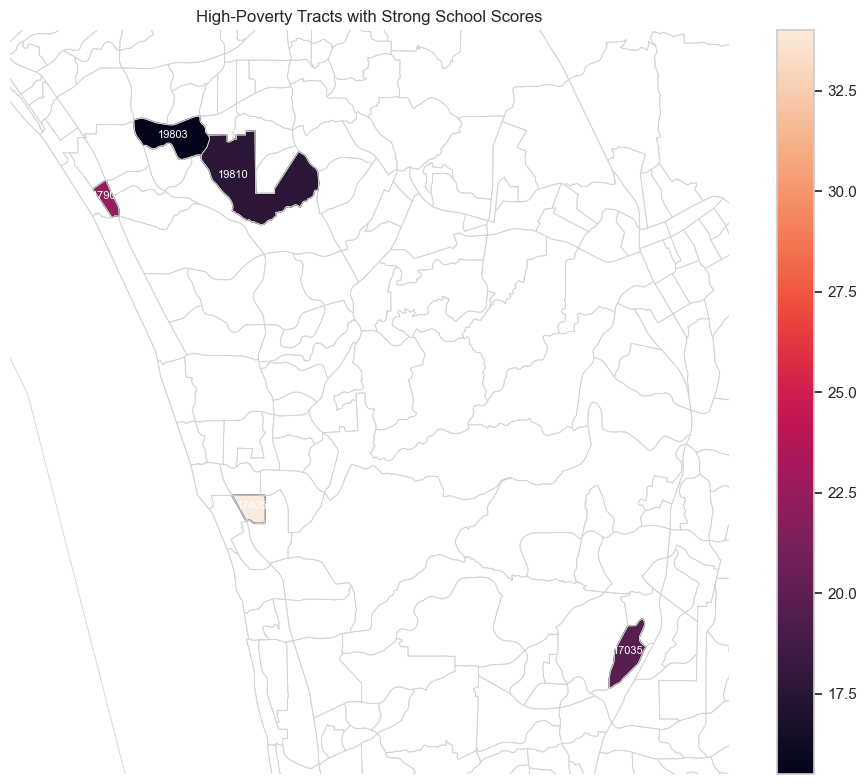

In [51]:
# zooming the map to the highlighted tracts

fig, ax = plt.subplots(figsize=(10, 8))

# background county tracts
sd_tract_gdf.boundary.plot(
    ax=ax,
    color='lightgray',
    linewidth=0.6)

# highlighted outlier tracts
outlier_map_gdf.plot(
    ax=ax,
    column='poverty_rate',
    legend=True,
    edgecolor='black',
    linewidth=1)

# finding the highlighted area bounds
min_x, min_y, max_x, max_y = (
    outlier_map_gdf.total_bounds)

x_pad = (max_x - min_x) * 0.15
y_pad = (max_y - min_y) * 0.15

ax.set_xlim(
    min_x - x_pad,
    max_x + x_pad)

ax.set_ylim(
    min_y - y_pad,
    max_y + y_pad)

# labeling the highlighted tracts
label_points = outlier_map_gdf.copy()
label_points['geometry'] = (
    label_points.geometry.representative_point())

for _, row in label_points.iterrows():
    ax.annotate(
        text=row['tract_id'][-5:],
        xy=(
            row.geometry.x,
            row.geometry.y),
        ha='center',
        fontsize=8,
        color='white')

ax.set_title(
    'High-Poverty Tracts with Strong School Scores')

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [53]:
# checking whether the outlier tracts contain schools or mainly inherit district scores

school_outlier_context = df.loc[
    df['tract_id'].isin(strong_school_outliers['tract_id']),
    [
        'tract_id',
        'tract_name',
        'school_academic_score',
        'poverty_rate',
        'school_count',
        'elementary_school_count',
        'middle_school_count',
        'high_school_count',
        'school_density',
        'district_name',
        'district_overlap_pct'
    ]
].sort_values(
    'poverty_rate',
    ascending=False)

school_outlier_context.T

,524,543,473,625,620
tract_id,06073017405,06073017902,06073017035,06073019810,06073019803
tract_name,Census Tract 174.05; San Diego County; California,Census Tract 179.02; San Diego County; California,Census Tract 170.35; San Diego County; California,Census Tract 198.10; San Diego County; California,Census Tract 198.03; San Diego County; California
school_academic_score,5.0,4.5,5.0,4.5,4.5
poverty_rate,34.0,22.5,19.8,17.6,15.5
school_count,1,1,1,4,1
elementary_school_count,1,1,1,1,1
middle_school_count,0,0,0,1,0
high_school_count,0,0,0,2,0
school_density,2.031782,3.215093,1.108841,1.028782,0.681807
district_name,Cardiff Elementary,Carlsbad Unified,Poway Unified,Carlsbad Unified,Carlsbad Unified
